# Credit Card Fraud Detection

## Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve,
                              average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Load Dataset

In [4]:

df = pd.read_csv('creditcard.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## EDA

📊 Dataset Info:
Total transactions : 284807
Fraudulent         : 492
Legitimate         : 284315
Fraud Percentage   : 0.1727%

Missing values: 0


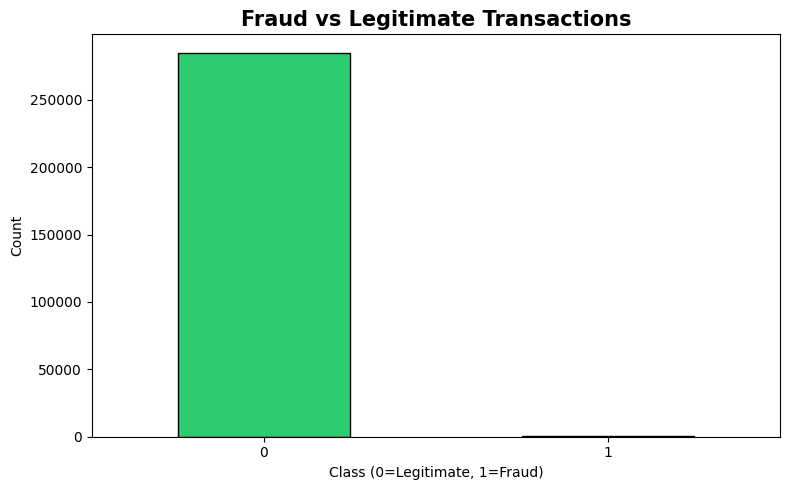

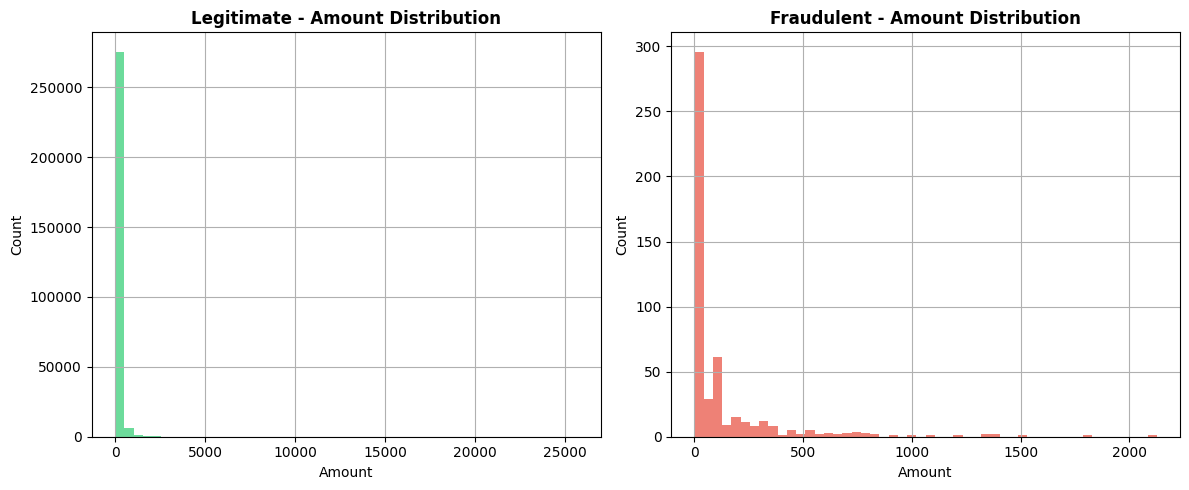


Average Legitimate Amount : $88.29
Average Fraudulent Amount : $122.21


In [5]:

print("📊 Dataset Info:")
print(f"Total transactions : {len(df)}")
print(f"Fraudulent         : {df['Class'].sum()}")
print(f"Legitimate         : {len(df) - df['Class'].sum()}")
print(f"Fraud Percentage   : {df['Class'].mean()*100:.4f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Class distribution
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['Class'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Fraud vs Legitimate Transactions', fontsize=15, fontweight='bold')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Transaction amount distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[df['Class']==0]['Amount'].hist(bins=50, color='#2ecc71', alpha=0.7)
plt.title('Legitimate - Amount Distribution', fontweight='bold')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[df['Class']==1]['Amount'].hist(bins=50, color='#e74c3c', alpha=0.7)
plt.title('Fraudulent - Amount Distribution', fontweight='bold')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

print(f"\nAverage Legitimate Amount : ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average Fraudulent Amount : ${df[df['Class']==1]['Amount'].mean():.2f}")

##  Correlation Heatmap

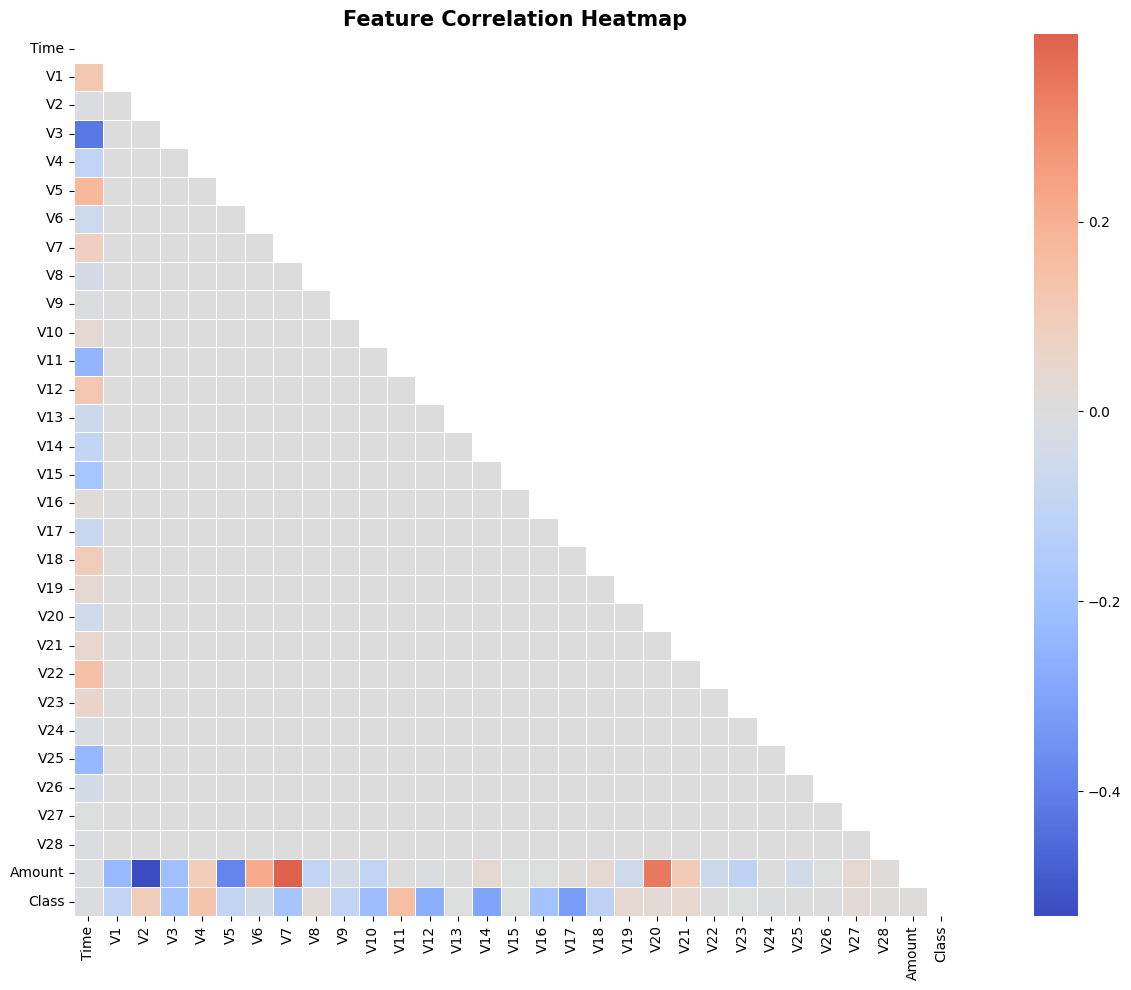

✅ Heatmap generated!


In [6]:

plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=False)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap generated!")

## Preprocessing

In [ ]:

# Scale Amount and Time columns
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time']   = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns
df_clean = df.drop(['Amount', 'Time'], axis=1)

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Preprocessing done!")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nTraining fraud cases   : {y_train.sum()}")
print(f"Training legit cases   : {len(y_train) - y_train.sum()}")

✅ Preprocessing done!
Training samples : 227845
Testing samples  : 56962

Training fraud cases   : 394
Training legit cases   : 227451


## SMOTE

Before SMOTE:
  Legitimate : 227451
  Fraudulent : 394

After SMOTE:
  Legitimate : 227451
  Fraudulent : 227451


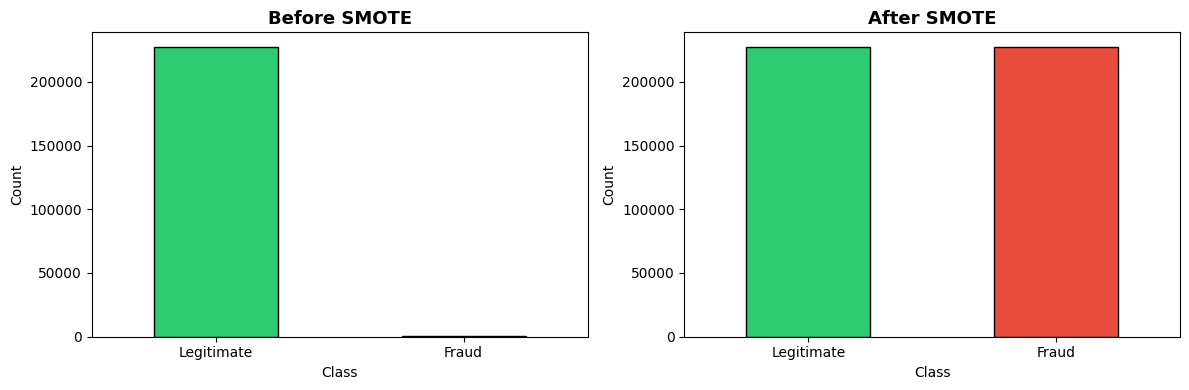

✅ SMOTE applied!


In [ ]:

print("Before SMOTE:")
print(f"  Legitimate : {(y_train==0).sum()}")
print(f"  Fraudulent : {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_sm==0).sum()}")
print(f"  Fraudulent : {(y_train_sm==1).sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [(y_train, 'Before SMOTE'), 
                                      (y_train_sm, 'After SMOTE')]):
    pd.Series(data).value_counts().plot(kind='bar', ax=ax,
              color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150)
plt.show()
print("✅ SMOTE applied!")

## Train models

In [9]:


# Model 1: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_sm, y_train_sm)
lr_pred      = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained!")

# Model 2: Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   n_jobs=-1, max_depth=10)
rf_model.fit(X_train_sm, y_train_sm)
rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest trained!")

Training Logistic Regression...
✅ Logistic Regression trained!

Training Random Forest...
✅ Random Forest trained!


## Evaluation

In [10]:


def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  📌 {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Avg Prec  : {average_precision_score(y_true, y_prob):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legitimate','Fraud'])}")

evaluate_model("Logistic Regression", y_test, lr_pred, lr_pred_prob)
evaluate_model("Random Forest",       y_test, rf_pred, rf_pred_prob)


  📌 Logistic Regression
  Accuracy  : 97.43%
  ROC-AUC   : 0.9698
  Avg Prec  : 0.7249

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  📌 Random Forest
  Accuracy  : 99.77%
  ROC-AUC   : 0.9800
  Avg Prec  : 0.7964

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.42      0.85      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.92      0.78     56962
weighted avg       1.00      1.00      1.00     56962



## Confusion Matrix

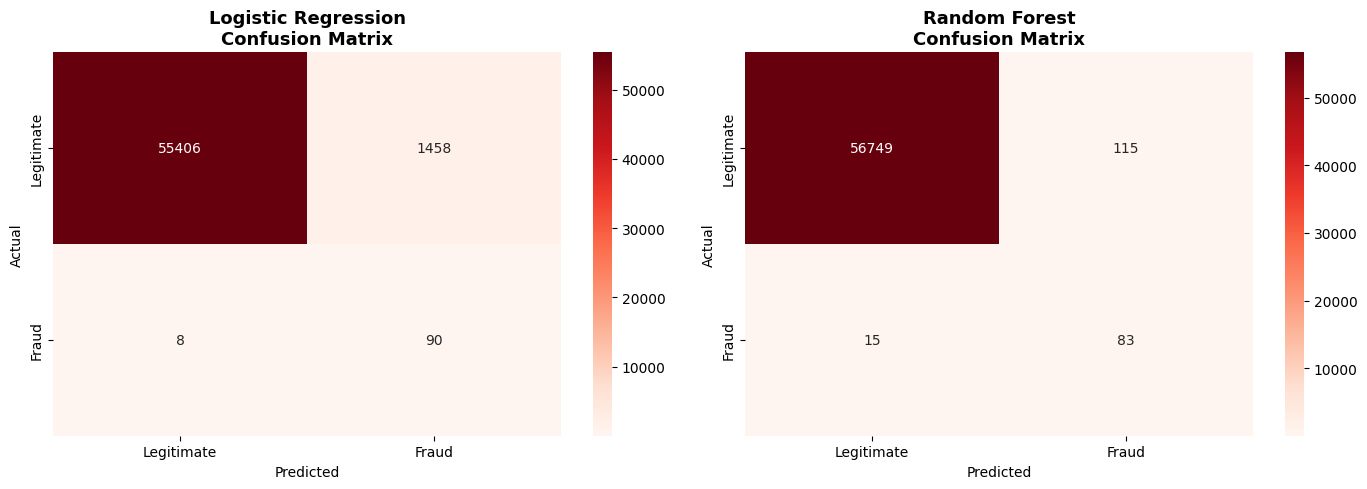

In [11]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_preds = [("Logistic Regression", lr_pred),
               ("Random Forest",       rf_pred)]

for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

##  ROC Curve

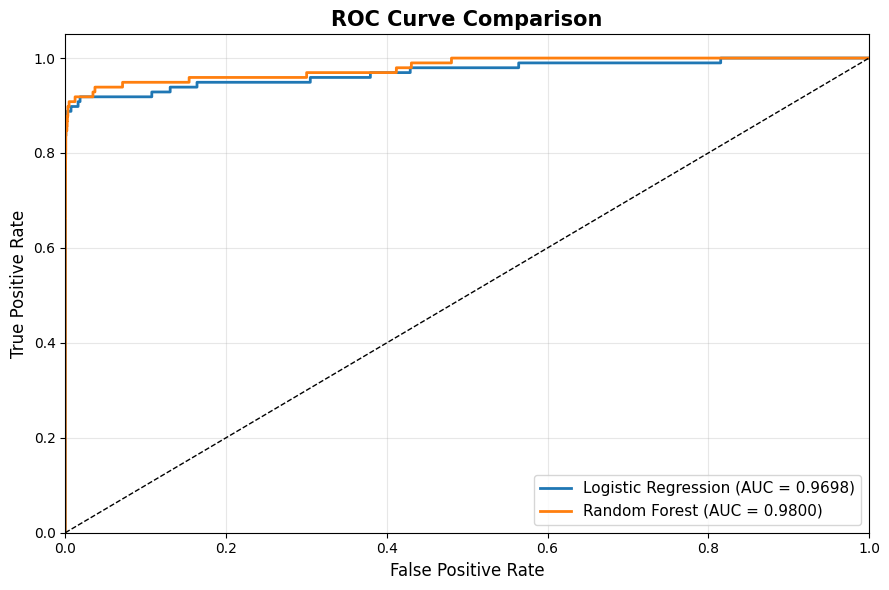

✅ ROC Curve saved!


In [12]:


plt.figure(figsize=(9, 6))

for name, y_prob in [("Logistic Regression", lr_pred_prob),
                      ("Random Forest",       rf_pred_prob)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")

## Feature Importance

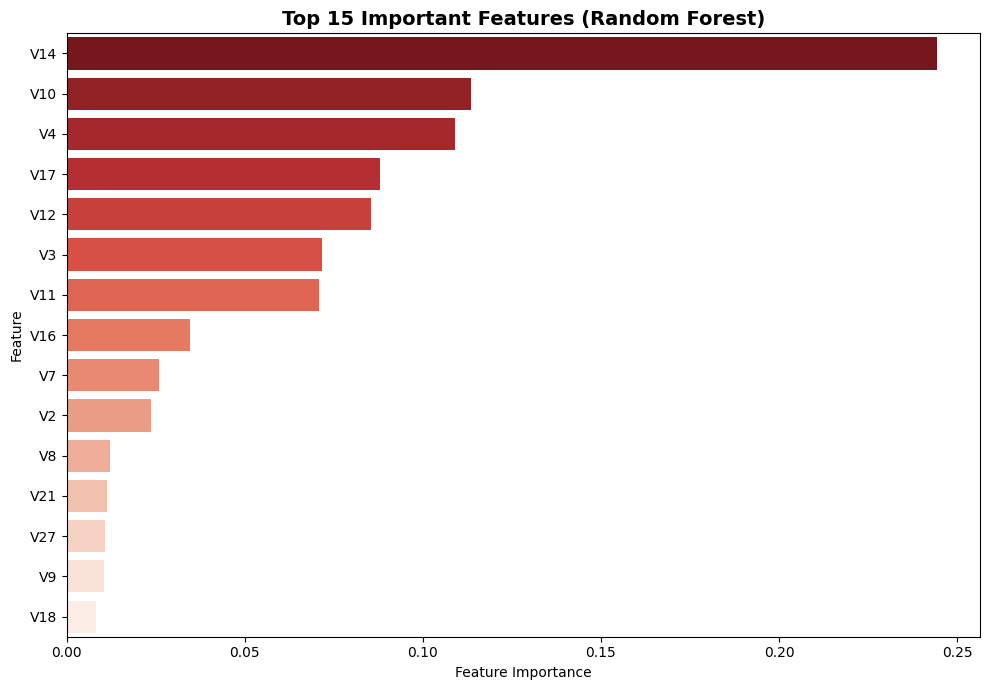

✅ Feature importance plotted!


In [ ]:


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', 
            data=feature_importance, palette='Reds_r')
plt.title('Top 15 Important Features (Random Forest)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance plotted!")

##  Predict Custom Transaction

In [ ]:


def predict_transaction(transaction_data):
    """
    transaction_data: list of 29 features 
    (V1-V28 + scaled_Amount + scaled_Time)
    """
    input_df = pd.DataFrame([transaction_data], columns=X.columns)
    
    lr_result = lr_model.predict(input_df)[0]
    rf_result = rf_model.predict(input_df)[0]
    
    lr_prob = lr_model.predict_proba(input_df)[0][1]
    rf_prob = rf_model.predict_proba(input_df)[0][1]
    
    lr_label = "🚨 FRAUD" if lr_result == 1 else "✅ Legitimate"
    rf_label = "🚨 FRAUD" if rf_result == 1 else "✅ Legitimate"
    
    print(f"\n💳 Transaction Prediction:")
    print(f"   Logistic Regression : {lr_label} (Fraud probability: {lr_prob:.4f})")
    print(f"   Random Forest       : {rf_label} (Fraud probability: {rf_prob:.4f})")

# Test with a real sample from dataset
sample_legit = X_test[y_test==0].iloc[0].values.tolist()
sample_fraud = X_test[y_test==1].iloc[0].values.tolist()

print("Testing with a LEGITIMATE transaction:")
predict_transaction(sample_legit)

print("\nTesting with a FRAUDULENT transaction:")
predict_transaction(sample_fraud)

Testing with a LEGITIMATE transaction:

💳 Transaction Prediction:
   Logistic Regression : ✅ Legitimate (Fraud probability: 0.0026)
   Random Forest       : ✅ Legitimate (Fraud probability: 0.0074)

Testing with a FRAUDULENT transaction:

💳 Transaction Prediction:
   Logistic Regression : 🚨 FRAUD (Fraud probability: 1.0000)
   Random Forest       : 🚨 FRAUD (Fraud probability: 0.9996)
